In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv file using read_csv
df = pd.read_csv("cleaning_challenge.csv")

### Data Understanding

In [3]:
df.head(10)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Details
0,INV-10001,Mecca,Recorded Subscription,532,266,266,2023-03-17,4.1,Laravel & PHP | Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,"2023, March 15",4.5,Laravel & PHP | Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,"2023, March 15",4.4,UI/UX Design | Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,"2023, March 15",4.7,UI/UX Design | Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,22-03-2023,4.6,React & Next.js | Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542,0,1542,1900-01-01,4.5,Flutter Development | Beginner
6,INV-10007,Khobar,Recorded Subscription,269,134,135,10-02-2023,4.5,Flutter Development | Beginner
7,INV-10008,Tabuk,Recorded Subscription,211,42,169,"2023, March 15",4.7,Data Analysis | Beginner
8,INV-10009,Riyadh,Recorded Subscription,397,0,397,"2023, March 15",?,Flutter Development | Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292,0,292,08-03-2023,4.6,Python Basics | Beginner


In [4]:
df.shape

(5002, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002 entries, 0 to 5001
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Invoice_ID       5002 non-null   object
 1   City             5002 non-null   object
 2   Course_Type      5002 non-null   object
 3   Price            5002 non-null   int64 
 4   Discount         5002 non-null   int64 
 5   Final_Total      5002 non-null   int64 
 6   Enrollment_Date  5002 non-null   object
 7   Rating           4952 non-null   object
 8   Course_Details   5002 non-null   object
dtypes: int64(3), object(6)
memory usage: 351.8+ KB


In [6]:
df.describe()

,Price,Discount,Final_Total
count,5002.000000,5002.000000,5002.000000
mean,716.730708,60.266094,656.464614
std,718.706955,76.638282,736.086976
min,200.000000,0.000000,100.000000
25%,293.000000,0.000000,231.000000
50%,404.500000,43.000000,323.000000
75%,599.750000,98.000000,528.750000
max,2999.000000,325.000000,2999.000000


In [7]:
df.tail()

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Details
4997,INV-14998,Mecca,Recorded Subscription,244,48,196,30-04-2023,4.1,React & Next.js | Beginner
4998,INV-14999,Mecca,Live Bootcamp,1559,0,1559,"2023, March 15",4.7,Laravel & PHP | Beginner
4999,INV-15000,Medina,Recorded Subscription,280,140,140,2023-07-17,4.7,Python Basics | Beginner
5000,INV-10006,Riyadh,lIVE bOOTCAMP,1542,0,1542,2023-03-12,4.5,Flutter Development | Beginner
5001,INV-10007,Khobar,rECORDED sUBSCRIPTION,269,134,135,10-02-2023,4.5,Flutter Development | Beginner


In [8]:
df.sample(5)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Details
2791,INV-12792,Jeddah,Recorded Subscription,280,0,280,2023-09-07,4.0,Data Analysis | Beginner
2052,INV-12053,Riyadh,Live Bootcamp,1548,0,1548,"2023, March 15",4.7,UI/UX Design | Beginner
3595,INV-13596,Medina,Recorded Subscription,339,67,272,2023-02-23,4.2,React & Next.js | Beginner
1258,INV-11259,Khobar,Recorded Subscription,368,0,368,2023-11-28,4.2,Python Basics | Intermediate
1217,INV-11218,Medina,Recorded Subscription,261,0,261,28-04-2023,4.0,Data Analysis | Beginner


### Data cleaning

In [9]:
# Creating a copy
clean_df = df.copy()

In [10]:
## spilt Course_Details coulmn
df[['Course_Name', 'Level']] = df['Course_Details'].str.split('|', expand=True)

In [11]:
df['Course_Name'] = df['Course_Name'].str.lower()

In [12]:
df = df.drop_duplicates()

In [13]:
df.drop('Course_Details', axis=1, inplace=True)

In [14]:
df['Enrollment_Date'] = pd.to_datetime(df['Enrollment_Date'], errors='coerce')

In [15]:
df.head()

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,2023-03-17,4.1,laravel & php,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,NaT,4.5,laravel & php,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,NaT,4.4,ui/ux design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,NaT,4.7,ui/ux design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,NaT,4.6,react & next.js,Beginner


In [16]:
df['Rating'] = df['Rating'].replace('?', None)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [17]:
df.head(10)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,2023-03-17,4.1,laravel & php,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,NaT,4.5,laravel & php,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,NaT,4.4,ui/ux design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,NaT,4.7,ui/ux design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,NaT,4.6,react & next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542,0,1542,1900-01-01,4.5,flutter development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269,134,135,NaT,4.5,flutter development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211,42,169,NaT,4.7,data analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397,0,397,NaT,NaN,flutter development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292,0,292,NaT,4.6,python basics,Beginner


In [18]:
def clean_price(df):
    df['Price'] = df['Price'].astype(str)
    df['Price'] = df['Price'].str.replace(r'[^0-9.]', '', regex=True)
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    return df

df = clean_price(df)

### Outliers Detection

In [19]:
invalid_ratings = df[(df['Rating'] > 5) | (df['Rating'] < 0)]
invalid_ratings

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level


In [20]:
outliers_dates = df[df['Enrollment_Date'] > pd.Timestamp.today()]
outliers_dates

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level


### After Cleaning


In [21]:
clean_df = df.copy()
clean_df.head()

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,2023-03-17,4.1,laravel & php,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,NaT,4.5,laravel & php,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,NaT,4.4,ui/ux design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,NaT,4.7,ui/ux design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,NaT,4.6,react & next.js,Beginner


In [22]:
# Display specific coulmns using loc function
clean_df.loc[:,["Course_Name", "Price", "City" ]].head(10)


,Course_Name,Price,City
0,laravel & php,532,Mecca
1,laravel & php,289,Jeddah
2,ui/ux design,474,Dammam
3,ui/ux design,265,Khobar
4,react & next.js,228,Mecca
5,flutter development,1542,Riyadh
6,flutter development,269,Khobar
7,data analysis,211,Tabuk
8,flutter development,397,Riyadh
9,python basics,292,Jeddah


In [26]:
clean_df.loc[clean_df["City"] == "Jeddah",["Course_Name", "Price", "City" ]].head(10)

,Course_Name,Price,City
1,laravel & php,289,Jeddah
9,python basics,292,Jeddah
10,python basics,210,Jeddah
11,react & next.js,328,Jeddah
17,laravel & php,299,Jeddah
18,laravel & php,2795,Jeddah
24,python basics,221,Jeddah
28,ui/ux design,318,Jeddah
33,python basics,314,Jeddah
41,ui/ux design,276,Jeddah


In [30]:
clean_df["Discount_Status"] = np.where(
    clean_df["Discount"] > 0 ,
    "Discounted", "Full Price"
)

In [31]:
def classify_rating(Rating):
    if Rating >= 4.5:
        return "High Rating"
    else:
        return "Normal"
clean_df["Rating_Status_apply"] = clean_df["Rating"].apply(classify_rating)
        

In [35]:
clean_df[["Rating","Rating_Status_apply","Discount","Discount_Status"]].sample(10)

,Rating,Rating_Status_apply,Discount,Discount_Status
4065,4.8,High Rating,0,Full Price
492,4.0,Normal,115,Discounted
2082,4.6,High Rating,51,Discounted
2843,4.6,High Rating,0,Full Price
2225,NaN,Normal,0,Full Price
1789,4.4,Normal,103,Discounted
1696,3.9,Normal,120,Discounted
90,4.9,High Rating,0,Full Price
4167,4.8,High Rating,0,Full Price
4297,4.8,High Rating,0,Full Price


## Matplotlib

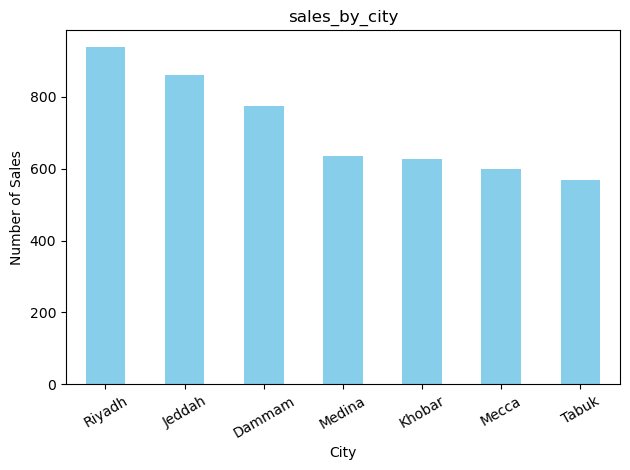

In [64]:
clean_df["City"].value_counts().plot(kind="bar" ,color ="skyblue")
plt.title("sales_by_city")
plt.xticks(rotation = 30)
plt.xlabel('City')
plt.ylabel('Number of Sales')
plt.tight_layout()
plt.show()


<Axes: xlabel='Discount_Status', ylabel='count'>

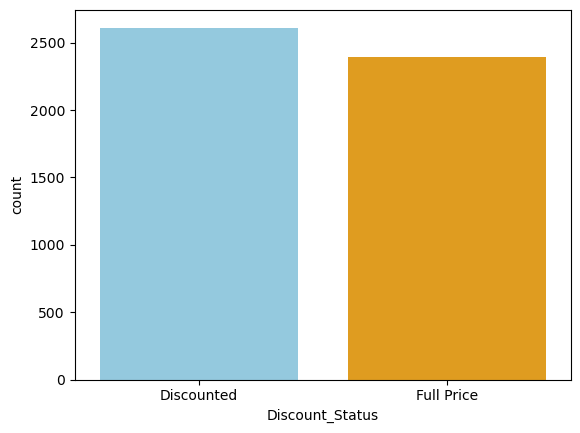

In [74]:
#sns.countplot(data = clean_df , x ="Discount_Status")
#plt.title("Discount vs Full Price Sales Count")
#plt.show

#sns.countplot(data =clean_df, x= "Discount_Status", hue="Discount_Status", palette=["skyblue", "orange"]), legend=False


#plt.title("Discount vs Full Price Sales Count")
#plt.xlabel("Purchase Type")
#plt.ylabel("Number of Sales")

#plt.show()
# if use this code make some problem show running like this:Passing palette without assigning hue is deprecated and will be removed in v0.14.0. Assign the x variable to hue and set legend=False for the same effect.sns.countplot(data =clean_df, x= "Discount_Status", palette=["skyblue", "orange"]),so in new version will be used like this way 
#كل الطرق صحيحه لكن اللي اعتمدتها هنا اللي هي تحت هي الافضل لان ذا استخدمنا اللي قبل بيطلع تحذير ان ذي الطريقه ماتناسب الاصدارات الجديده
#❗ ما عاد يدعم استخدام palette بدون hue في الإصدارات الجاية
sns.countplot( data=clean_df, x="Discount_Status", hue="Discount_Status", palette=["skyblue", "orange"], legend=False)

In [58]:
top_Course = clean_df["Course_Name"].value_counts().head(5)
top_Course 

Course_Name
python basics           871
ui/ux design            845
laravel & php           839
react & next.js         830
flutter development     827
Name: count, dtype: int64

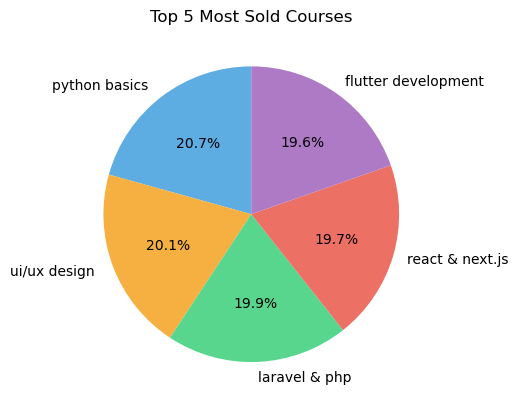

In [78]:
#top_Course .plot(kind="bar") plt.title(" Top Course") plt.xticks(rotation = 45) plt.show - another soultion

# اضافة الوان وشكل بار
#top_Course.plot(kind="pie", color=["skyblue", "orange", "lightgreen", "pink", "purple"])

#plt.title("Top 5 Most Sold Courses")
#plt.xlabel("Course Name")
#plt.ylabel("Number of Sales")

#plt.xticks(rotation=45)

# إضافة أرقام فوق الأعمدة
#for i, v in enumerate(top_Course):
   # plt.text(i, v, str(v), ha='center')

#plt.tight_layout()
#plt.show()

top_Course.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#5DADE2", "#F5B041", "#58D68D", "#EC7063", "#AF7AC5"],
    startangle=90
)

plt.title("Top 5 Most Sold Courses")
plt.ylabel("")  # لإخفاء اسم العمود
plt.show()
